In [9]:
import sys, os
from dotenv import load_dotenv


load_dotenv()

True

In [ ]:
# Resolve certificate path from workspace root
from pathlib import Path

workspace_root = Path.cwd().resolve()
if workspace_root.name.lower() == "sg" and workspace_root.parent.name.lower() == "notebooks":
    workspace_root = workspace_root.parent.parent

cert_path = str((workspace_root / "certs" / "knapp.pem").resolve())

# Verify cert exists
if not Path(cert_path).exists():
    print(f"⚠️  Warning: Certificate not found at {cert_path}")
    cert_path = None
else:
    print(f"✓ Certificate found: {cert_path}")


In [11]:
import httpx

http_client = httpx.Client(verify=cert_path)

c:\Users\lame\Desktop\Work\HyperGraphReasoning\venv\Lib\site-packages\httpx\_config.py:51: DeprecationWarning: `verify=<str>` is deprecated. Use `verify=ssl.create_default_context(cafile=...)` or `verify=ssl.create_default_context(capath=...)` instead.
  warnings.warn(message, DeprecationWarning)


In [12]:
import httpx
from langchain_openai import ChatOpenAI


client = ChatOpenAI(
                    base_url=os.getenv("URL"),
                    model=os.getenv("MODEL_NAME"),
                    api_key=os.getenv("OPENAI_API_KEY"),
                    http_client=http_client,
                    max_tokens = 20000
                    )

client.invoke("Hello world")

AIMessage(content='\n\nHello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 455, 'prompt_tokens': 12, 'total_tokens': 467, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen3.5', 'system_fingerprint': None, 'id': 'chatcmpl-a3137592558385c5', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d4e43-f62e-7af0-912b-6f312eeee91d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 455, 'total_tokens': 467, 'input_token_details': {}, 'output_token_details': {}})

In [ ]:
# Cell 5: Canonical project paths (stable across working directories)
from pathlib import Path

cwd = Path.cwd().resolve()
if cwd.name.lower() == "sg" and cwd.parent.name.lower() == "notebooks":
    workspace_root = cwd.parent.parent
else:
    workspace_root = cwd

# Source docs
doc_data_dir = str((workspace_root / "Data").resolve())

# Standardized artifacts layout
artifacts_root = (workspace_root / "artifacts" / "sg").resolve()
data_dir = str((artifacts_root / "graphs").resolve())
data_dir_output = str((artifacts_root / "integrated").resolve())
cache_dir = str((workspace_root / "artifacts" / "cache" / "chunks").resolve())
embedding_file = "hypergraph_embeedings.pkl"

# Make dirs + share cache dir with GraphReasoning internals
for p in [Path(data_dir), Path(data_dir_output), Path(cache_dir)]:
    p.mkdir(parents=True, exist_ok=True)
os.environ["GRAPH_REASONING_CACHE_DIR"] = cache_dir

# Prefer local package over installed site-package
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

print(f"workspace_root: {workspace_root}")
print(f"doc_data_dir:   {doc_data_dir}")
print(f"data_dir:       {data_dir}")
print(f"data_dir_output:{data_dir_output}")
print(f"cache_dir:      {cache_dir}")

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\lame\AppData\Local\Temp\ipykernel_32096\1160713822.py:3: SyntaxWarning: invalid escape sequence '\S'
  doc_data_dir = 'Notebooks\SG\Data' #place where you keep your markdown files


In [14]:
# Use local BGE server (running on port 8080) for hypernode embeddings
import os
import torch
import numpy as np
import httpx
from GraphReasoning.graph_tools import load_embeddings, save_embeddings, generate_hypernode_embeddings

class LocalBGEClient:
    def __init__(self, base_url="http://127.0.0.1:8080", model="BAAI/bge-m3", timeout=120.0):
        self.base_url = base_url.rstrip("/")
        self.model = model
        self.client = httpx.Client(timeout=timeout)

    def encode(self, text: str):
        # Try OpenAI-compatible embeddings route first
        try:
            r = self.client.post(
                f"{self.base_url}/v1/embeddings",
                json={"model": self.model, "input": text},
            )
            if r.status_code < 400:
                data = r.json()
                vec = data["data"][0]["embedding"]
                return np.array(vec, dtype=np.float32)
        except Exception:
            pass

        # Fallback: common sentence-transformers style API
        r = self.client.post(
            f"{self.base_url}/embed",
            json={"model": self.model, "input": [text]},
        )
        r.raise_for_status()
        data = r.json()
        if "embeddings" in data:
            vec = data["embeddings"][0]
        elif "data" in data and isinstance(data["data"], list):
            vec = data["data"][0]
        else:
            raise ValueError(f"Unsupported embedding response format: {list(data.keys())}")
        return np.array(vec, dtype=np.float32)

embedding_tokenizer = None
embedding_model = LocalBGEClient(base_url="http://127.0.0.1:8080", model="BAAI/bge-m3")

generate_new_embeddings = True
if os.path.exists(f"{data_dir}/{embedding_file}"):
    print("Found existing embedding file")
    generate_new_embeddings = False

# Ensure output folder exists before saving
os.makedirs(data_dir, exist_ok=True)

with torch.no_grad():
    if generate_new_embeddings:
        # Use nodes from an existing hypergraph variable if present; otherwise embed nothing.
        if "H" in globals() and hasattr(H, "nodes"):
            nodes = list(H.nodes)
        else:
            nodes = []

        node_embeddings = generate_hypernode_embeddings(
            nodes,
            embedding_tokenizer,
            embedding_model,
        )
        save_embeddings(node_embeddings, f"{data_dir}/{embedding_file}")
    else:
        node_embeddings = load_embeddings(f"{data_dir}/{embedding_file}")

print(f"Embeddings loaded for {len(node_embeddings)} nodes via local BGE server on :8080")

Found existing embedding file
Embeddings loaded for 300 nodes via local BGE server on :8080


In [15]:
# Cell 7: Load markdown documents for graph generation
from pathlib import Path

# Resolve doc_data_dir robustly across different notebook working directories
raw_root = Path(doc_data_dir)
candidates = []
if raw_root.is_absolute():
    candidates.append(raw_root)
else:
    candidates.append((Path.cwd() / raw_root).resolve())
    # notebook location is .../Notebooks/SG, so workspace root is two levels up
    workspace_root = (Path.cwd().resolve().parent if Path.cwd().name.lower() == "sg" else Path.cwd().resolve())
    candidates.append((workspace_root / raw_root).resolve())
    candidates.append((Path.cwd().resolve().parent.parent / raw_root).resolve())

# Pick the first existing directory
root = next((c for c in candidates if c.exists()), candidates[0])

doc_list = []

# 1) Direct .md files under doc_data_dir
if root.exists():
    doc_list.extend([str(p) for p in root.glob("*.md")])

# 2) Fallback pattern: doc_data_dir/<folder>/<folder>.md
if not doc_list and root.exists():
    for folder in root.iterdir():
        if folder.is_dir():
            candidate = folder / f"{folder.name}.md"
            if candidate.exists():
                doc_list.append(str(candidate))

# Final cleanup and ordering
doc_list = sorted([p for p in doc_list if Path(p).exists()])

print(f"Resolved doc_data_dir to: {root}")
print(f"Loaded {len(doc_list)} markdown documents")
if doc_list:
    print("Example:", doc_list[0])

Resolved doc_data_dir to: C:\Users\lame\Desktop\Work\HyperGraphReasoning\Notebooks\SG\Data
Loaded 3 markdown documents
Example: C:\Users\lame\Desktop\Work\HyperGraphReasoning\Notebooks\SG\Data\20230515_Migros_Online_Technische Spezifikation.md


In [16]:
# Cell 8: Threading + merge checkpoint setup
import os
import re
import glob

# Notebook defaults (single-threaded); override from CLI args when provided
try:
    thread_i = int(sys.argv[1])
    total_threads = int(sys.argv[2])
except Exception:
    thread_i = 0
    total_threads = 1

merge_every = 100

# Ensure output directories exist
os.makedirs(data_dir, exist_ok=True)
os.makedirs(data_dir_output, exist_ok=True)

# Resume index in merging mode
INT_PREFIX = re.compile(r"^(\d+)_")

def extract_idx(path: str) -> int:
    name = os.path.basename(path)
    match = INT_PREFIX.match(name)
    return int(match.group(1)) if match else -1

if total_threads == 1:
    merged_graph_list = sorted(
        glob.glob(f"{data_dir_output}/*_integrated.pkl"),
        reverse=True,
        key=extract_idx,
    )
    current_merged_i = extract_idx(merged_graph_list[0]) if merged_graph_list else 0
else:
    current_merged_i = 0

print(f"Thread: {thread_i}/{total_threads}")
print(f"merge_every: {merge_every}")
print(f"current_merged_i: {current_merged_i}")
print(f"doc_count: {len(doc_list)}")

Thread: 0/1
merge_every: 100
current_merged_i: 1
doc_count: 3


In [17]:
# Cell 10: Minimal LLM helpers used by Cell 9 (generate / generate_figure)
import base64
from pathlib import Path
from typing import List

from pydantic import BaseModel

try:
    import instructor
except Exception:
    instructor = None

class Event(BaseModel):
    source: List[str]
    target: List[str]
    relation: str

class HypergraphJSON(BaseModel):
    events: List[Event]

response_model = HypergraphJSON

system_prompt = (
    "You extract scientific relations from a context chunk. "
    "Return strict JSON with one top-level key 'events'. "
    "Each event must include: source (list[str]), target (list[str]), relation (str)."
)

def _get_raw_create_fn():
    # Try likely locations depending on langchain_openai version
    try:
        return client.chat.completions.create
    except Exception:
        pass
    try:
        return client.client.chat.completions.create
    except Exception:
        pass
    return None

def generate(system_prompt=system_prompt, prompt="", temperature=0.333, max_tokens=20000, response_model=HypergraphJSON):
    # Prefer Instructor structured output when available
    if instructor is not None:
        create_fn = _get_raw_create_fn()
        if create_fn is not None:
            try:
                create = instructor.patch(create=create_fn, mode=instructor.Mode.JSON_SCHEMA)
                messages = [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": prompt},
                ]
                return create(
                    messages=messages,
                    model=os.getenv("MODEL_NAME"),
                    max_tokens=max_tokens,
                    temperature=temperature,
                    response_model=response_model,
                )
            except Exception as e:
                print(f"[generate] structured call failed, fallback to empty events: {e!r}")

    # Safe fallback so the pipeline remains executable
    return HypergraphJSON(events=[])

def image_to_base64_data_uri(file_path):
    with open(file_path, "rb") as image_file:
        base64_data = base64.b64encode(image_file.read()).decode("utf-8")
        return f"data:image/png;base64,{base64_data}"

def generate_figure(image, system_prompt=system_prompt, prompt="", temperature=0.0):
    try:
        pwd = os.getcwd()
        image_rel = image.split(pwd)[-1]
        image_path = list(Path(".").glob(f"**/{image_rel}", case_sensitive=False))[0]
        image_uri = image_to_base64_data_uri(image_path)

        msg = [
            {
                "type": "text",
                "text": "Describe this figure in technical detail.",
            },
            {
                "type": "image_url",
                "image_url": {"url": image_uri},
            },
        ]

        resp = client.invoke([
            {"role": "system", "content": "You are an assistant who describes scientific figures."},
            {"role": "user", "content": msg},
        ])
        return getattr(resp, "content", "") or ""
    except Exception:
        return ""

print("Cell 10 ready: generate() and generate_figure() defined")

Cell 10 ready: generate() and generate_figure() defined


In [18]:
# Cell 9: Generate per-doc KGs and merge into integrated graph
import os
import sys
import time
import pickle
from datetime import datetime

import torch
import hypernetx as hnx

# Prefer local workspace package over site-packages
workspace_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

from GraphReasoning.graph_generation import make_hypergraph_from_text, add_new_hypersubgraph_from_text
from GraphReasoning.graph_tools import save_embeddings

# Start global graph from latest integrated checkpoint if available
G = None
if total_threads == 1:
    merged_graph_list = sorted(
        [p for p in glob.glob(f"{data_dir_output}/*_integrated.pkl") if os.path.exists(p)],
        reverse=True,
        key=extract_idx,
    )
    if merged_graph_list:
        try:
            with open(merged_graph_list[0], "rb") as f:
                G = pickle.load(f)
            print(f"Loaded existing integrated graph: {merged_graph_list[0]}")
        except Exception as e:
            print(f"Could not load previous integrated graph: {e!r}")

with torch.no_grad():
    for i, doc in enumerate(doc_list):
        if i % total_threads != thread_i:
            continue
        if i < current_merged_i:
            continue

        title = os.path.basename(doc).rsplit(".md", 1)[0]
        graph_root = f"{i}_{title[:100]}"
        graph_path = os.path.join(data_dir, f"{graph_root}.pkl")

        with open(doc, "r", encoding="utf-8") as f:
            txt = f.read()

        # Build document subgraph if not present
        if not os.path.exists(graph_path):
            if callable(globals().get("generate")) and callable(globals().get("generate_figure")):
                print(f"[generation] Building KG for doc {i}: {title}")
                try:
                    t0 = datetime.now()
                    graph_path, _, _, _ = make_hypergraph_from_text(
                        txt,
                        generate,
                        generate_figure,
                        image_list="",
                        graph_root=graph_root,
                        do_distill=False,
                        do_relabel=False,
                        chunk_size=10000,
                        chunk_overlap=0,
                        repeat_refine=0,
                        verbatim=False,
                        data_dir=data_dir,
                    )
                    print(f"[generation] done in {datetime.now() - t0}")
                except Exception as e:
                    print(f"[generation] failed for doc {i}: {e!r}")
                    time.sleep(2)
                    continue
            else:
                print("[generation] Skipped: define generate() and generate_figure() first")
                continue

        # Load generated subgraph
        try:
            with open(graph_path, "rb") as f:
                H0 = pickle.load(f)
            H_doc = hnx.Hypergraph(
                H0.incidence_dict,
                edge_attr={"DOI": {eid: title for eid in H0.incidence_dict}},
            )
        except Exception as e:
            print(f"[merge] failed loading doc graph {graph_path!r}: {e!r}")
            continue

        integrated_path = os.path.join(data_dir_output, f"{graph_root}_integrated.pkl")
        if os.path.exists(integrated_path):
            print(f"[merge] already exists, skipping: {integrated_path}")
            continue

        if G is None:
            G = H_doc
            with open(integrated_path, "wb") as f:
                pickle.dump(G, f)
            print(f"[merge] initialized integrated graph with doc {i}")
        else:
            do_simplify_graph = (i % merge_every == 0)
            size_threshold = 10 if do_simplify_graph else 0

            try:
                integrated_path, G, _, node_embeddings, _ = add_new_hypersubgraph_from_text(
                    txt="",
                    node_embeddings=node_embeddings,
                    tokenizer=embedding_tokenizer,
                    model=embedding_model,
                    original_graph=G,
                    data_dir_output=data_dir_output,
                    graph_root=graph_root,
                    do_simplify_graph=do_simplify_graph,
                    do_relabel=False,
                    size_threshold=size_threshold,
                    do_update_node_embeddings=do_simplify_graph,
                    repeat_refine=0,
                    similarity_threshold=0.9,
                    do_Louvain_on_new_graph=False,
                    return_only_giant_component=False,
                    save_common_graph=False,
                    G_to_add=H_doc,
                    graph_pkl_to_add=None,
                    sub_dfs=[],
                    verbatim=True,
                )
                save_embeddings(node_embeddings, os.path.join(data_dir, embedding_file))
                print(f"[merge] merged doc {i}; embeddings saved")
            except Exception as e:
                print(f"[merge] failed for doc {i}: {e!r}")

print("Cell 9 finished")

Loaded existing integrated graph: ./GRAPHDATA_OUTPUT_paper\1_ZBI_201307958_ML_3 1_integrated.pkl
[merge] already exists, skipping: ./GRAPHDATA_OUTPUT_paper\1_ZBI_201307958_ML_3 1_integrated.pkl
[generation] Building KG for doc 2: ZBI_201307958_de_3 1
Number of chunks = 27
Generating hypergraph...
Error during KG generation - skipping this chunk!: "None of ['edge'] are in the columns"
Skipping chunk 7644a737c893d12d7221acd6a375704b – returned non-Hypergraph
Generating hypergraph...
Error during KG generation - skipping this chunk!: "None of ['edge'] are in the columns"
Skipping chunk ebcc8b02309db9fd6656513385e65d6a – returned non-Hypergraph
Generating hypergraph...
Error during KG generation - skipping this chunk!: "None of ['edge'] are in the columns"
Skipping chunk db64f293696d53ccd6a9abb588a6abcc – returned non-Hypergraph
Generating hypergraph...
Error during KG generation - skipping this chunk!: "None of ['edge'] are in the columns"
Skipping chunk 6af47d3215b694d0de839d63c9e0d671 –

## Visualize generated hypergraphs
Use the next cells to load the newest integrated `.pkl` file and render an interactive co-occurrence network plus embedding plots.

In [ ]:
# Cell 11: Load latest integrated hypergraph and show quick stats
import os
import glob
import pickle
from itertools import combinations

import networkx as nx
from pyvis.network import Network
from IPython.display import IFrame, display

# Resolve defaults if not defined earlier
if "data_dir_output" not in globals():
    data_dir_output = str((Path.cwd().resolve() / "artifacts" / "sg" / "integrated").resolve())

integrated_files = sorted(glob.glob(f"{data_dir_output}/*_integrated.pkl"), key=os.path.getmtime)
if not integrated_files:
    raise FileNotFoundError(f"No integrated hypergraph found in {data_dir_output}")

latest_integrated = integrated_files[-1]
print("Using:", latest_integrated)

with open(latest_integrated, "rb") as f:
    H = pickle.load(f)

edge_count = len(H.edges)
node_count = len(H.nodes)
print(f"Hypergraph stats -> nodes: {node_count}, hyperedges: {edge_count}")

# Build a node co-occurrence graph from each hyperedge
G_viz = nx.Graph()
for edge_id, members in H.incidence_dict.items():
    members = list(members)
    for n in members:
        if not G_viz.has_node(n):
            G_viz.add_node(n)
    for u, v in combinations(members, 2):
        if G_viz.has_edge(u, v):
            G_viz[u][v]["weight"] += 1
        else:
            G_viz.add_edge(u, v, weight=1)

print(f"Projection graph -> nodes: {G_viz.number_of_nodes()}, edges: {G_viz.number_of_edges()}")

# Optional downsample for responsiveness
max_nodes = 400
if G_viz.number_of_nodes() > max_nodes:
    top_nodes = sorted(G_viz.degree, key=lambda x: x[1], reverse=True)[:max_nodes]
    keep = {n for n, _ in top_nodes}
    G_viz = G_viz.subgraph(keep).copy()
    print(f"Downsampled projection to top-{max_nodes} degree nodes")

# Interactive HTML with pyvis
net = Network(height="850px", width="100%", bgcolor="#ffffff", font_color="#222222")
net.from_nx(G_viz)
net.repulsion(node_distance=140, spring_length=180)

html_path = os.path.join(data_dir_output, "latest_integrated_projection.html")
net.save_graph(html_path)
print("Saved interactive visualization:", html_path)
display(IFrame(src=html_path, width="100%", height=900))

Using: ./GRAPHDATA_OUTPUT_paper\1_ZBI_201307958_ML_3 1_integrated.pkl
Hypergraph stats -> nodes: 300, hyperedges: 167
Projection graph -> nodes: 300, edges: 169
Saved interactive visualization: ./GRAPHDATA_OUTPUT_paper\latest_integrated_projection.html


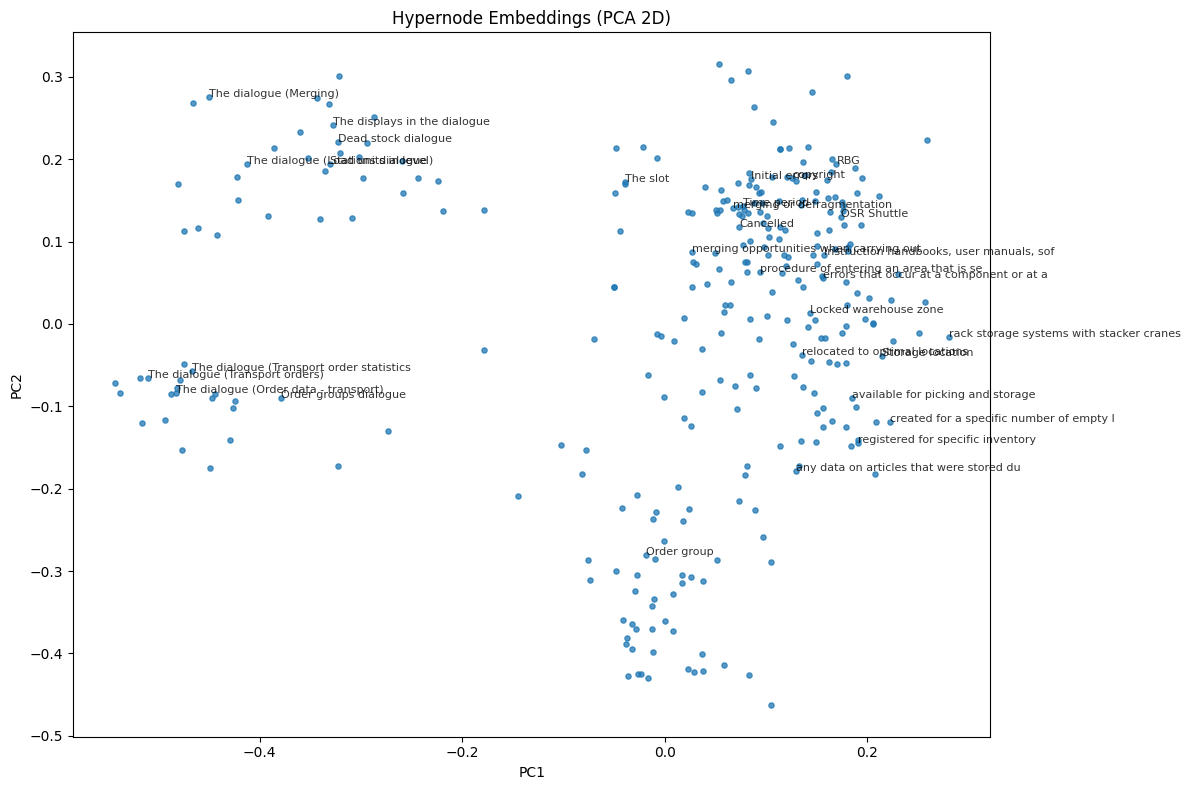

Loaded and visualized 300 embeddings from ./GRAPHDATA_paper\hypergraph_embeedings.pkl


In [ ]:
# Cell 12: Visualize node embeddings in 2D (package-independent)
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

if "data_dir" not in globals():
    data_dir = str((Path.cwd().resolve() / "artifacts" / "sg" / "graphs").resolve())
if "embedding_file" not in globals():
    embedding_file = "hypergraph_embeedings.pkl"

emb_path = os.path.join(data_dir, embedding_file)
if not os.path.exists(emb_path):
    print(f"Embedding file not found: {emb_path}")
else:
    with open(emb_path, "rb") as f:
        emb = pickle.load(f)

    if isinstance(emb, dict) and emb:
        labels = list(emb.keys())
        X = np.vstack([np.asarray(emb[k], dtype=float) for k in labels])

        pca = PCA(n_components=2)
        pts = pca.fit_transform(X)

        plt.figure(figsize=(12, 8))
        plt.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.75)

        # annotate only top-N by vector norm for readability
        top_n = min(30, len(labels))
        norms = np.linalg.norm(X, axis=1)
        top_idx = np.argsort(norms)[-top_n:]
        for idx in top_idx:
            plt.text(pts[idx, 0], pts[idx, 1], str(labels[idx])[:40], fontsize=8, alpha=0.8)

        plt.title("Hypernode Embeddings (PCA 2D)")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.tight_layout()
        plt.show()
        print(f"Loaded and visualized {len(labels)} embeddings from {emb_path}")
    else:
        print(f"Unexpected embedding format in {emb_path}")